In [1]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np

In [2]:
res = pd.read_csv("results.csv")
res

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
0,0,7ea09_00000,0,0.999157,least_confidence,1,223.054657
1,1,7ea09_00000,1,0.805749,least_confidence,1,223.054657
2,2,7ea09_00000,2,0.738358,least_confidence,1,223.054657
3,3,7ea09_00000,3,0.998262,least_confidence,1,223.054657
4,4,7ea09_00000,4,0.792850,least_confidence,1,223.054657
...,...,...,...,...,...,...,...
3760,3760,7ea09_00024,246,0.968012,random,5,237.972241
3761,3761,7ea09_00024,247,0.865894,random,5,237.972241
3762,3762,7ea09_00024,248,0.998262,random,5,237.972241
3763,3763,7ea09_00024,249,0.874157,random,5,237.972241


In [3]:
res[res.strategy=="random"]

,Unnamed: 0,trial_id,iteration,test_metric,strategy,seed,score
2761,2761,7ea09_00020,0,0.998262,random,1,211.336256
2762,2762,7ea09_00020,1,0.749192,random,1,211.336256
2763,2763,7ea09_00020,2,0.998262,random,1,211.336256
2764,2764,7ea09_00020,3,0.849192,random,1,211.336256
2765,2765,7ea09_00020,4,0.998262,random,1,211.336256
...,...,...,...,...,...,...,...
3760,3760,7ea09_00024,246,0.968012,random,5,237.972241
3761,3761,7ea09_00024,247,0.865894,random,5,237.972241
3762,3762,7ea09_00024,248,0.998262,random,5,237.972241
3763,3763,7ea09_00024,249,0.874157,random,5,237.972241


In [4]:
aucs = res.drop_duplicates(subset=["strategy","seed"])
agg = aucs.groupby("strategy")["score"]
mean_aucs, std_aucs = agg.mean(), agg.std()
aucs = pd.concat((mean_aucs, std_aucs), axis=1)
aucs.columns = ["avg", "stdv"]
aucs["score"] = aucs.apply(lambda row: f"{row.avg:.2f} ± {row.stdv:.2f}"  ,axis=1)
label_to_auc = dict(zip(aucs.index, aucs["score"]))

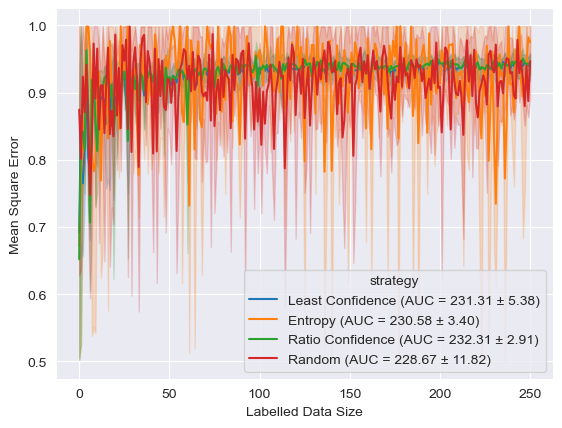

In [5]:
sns.set_style("darkgrid")

sns.lineplot(data=res, x="iteration", y="test_metric", hue="strategy")
plt.ylabel("Mean Square Error")
plt.xlabel("Labelled Data Size")
# _ = plt.xticks(np.arange(0,26), np.arange(0,26)*10 + 20, rotation=45)

ax = plt.gca()
legend = ax.get_legend()
for text in legend.get_texts():
    label = text.get_text()
    new_label = f"{label.replace('_', ' ').title()} (AUC = {label_to_auc[label]})"
    text.set_text(new_label)
    

for spine in ax.spines.values():
    spine.set_visible(False)